## 0. 一键训练两个模型（ResMLP + MSResNet）并输出曲线/混淆矩阵

该单元会按相同数据切分依次训练 `resmlp` 与 `msresnet`，分别输出：
- train/val 的 loss 曲线
- train/val 的 accuracy 曲线
- 测试集混淆矩阵与分类报告

device: cuda:0
DATA_ROOT: c:\projects\music_eeg\music_eeg\processed_data

===== Train variant: resmlp =====
[resmlp] Epoch 001 | train_loss=1.1823 val_loss=3.5840 train_acc=0.5754 val_acc=0.2005
[resmlp] Epoch 002 | train_loss=0.4349 val_loss=3.9107 train_acc=0.8410 val_acc=0.2598
[resmlp] Epoch 003 | train_loss=0.2695 val_loss=3.5937 train_acc=0.9018 val_acc=0.2983
[resmlp] Epoch 004 | train_loss=0.1868 val_loss=3.8404 train_acc=0.9346 val_acc=0.3215
[resmlp] Epoch 005 | train_loss=0.1582 val_loss=4.1073 train_acc=0.9448 val_acc=0.3178
[resmlp] Epoch 006 | train_loss=0.1246 val_loss=4.1977 train_acc=0.9550 val_acc=0.3352
[resmlp] Epoch 007 | train_loss=0.1086 val_loss=3.9760 train_acc=0.9624 val_acc=0.3396
[resmlp] Epoch 008 | train_loss=0.0977 val_loss=4.1467 train_acc=0.9654 val_acc=0.3311
[resmlp] Epoch 009 | train_loss=0.0814 val_loss=4.4468 train_acc=0.9712 val_acc=0.3144
[resmlp] Epoch 010 | train_loss=0.0788 val_loss=4.5832 train_acc=0.9725 val_acc=0.3295
[resmlp] Epoch 011 | t

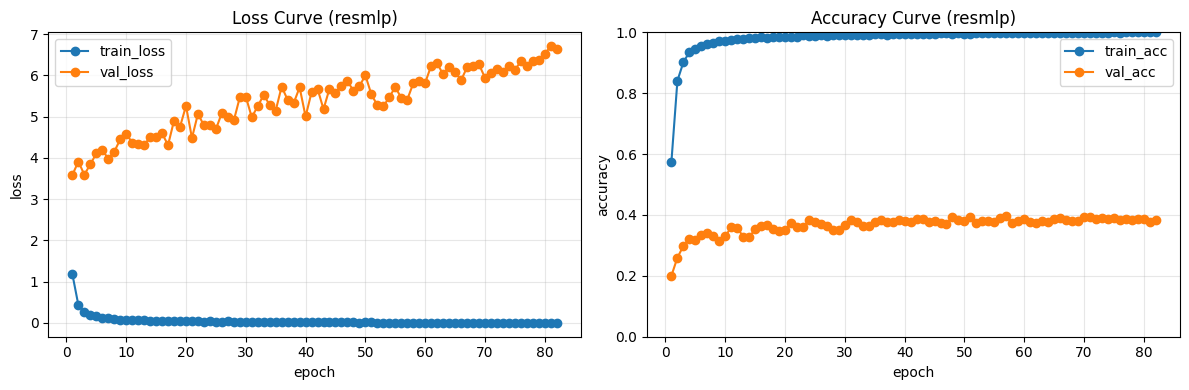

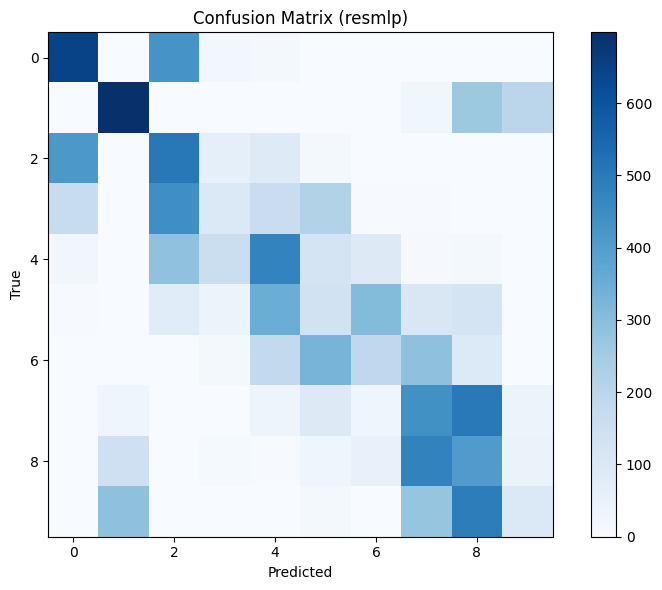


===== Train variant: msresnet =====
[msresnet] Epoch 001 | train_loss=2.2818 val_loss=2.3543 train_acc=0.1311 val_acc=0.0988
[msresnet] Epoch 002 | train_loss=2.2495 val_loss=2.3628 train_acc=0.1589 val_acc=0.1093
[msresnet] Epoch 003 | train_loss=2.1929 val_loss=2.5045 train_acc=0.1898 val_acc=0.0814
[msresnet] Epoch 004 | train_loss=2.1152 val_loss=2.5433 train_acc=0.2187 val_acc=0.1078
[msresnet] Epoch 005 | train_loss=2.0499 val_loss=2.5379 train_acc=0.2453 val_acc=0.0840
[msresnet] Epoch 006 | train_loss=1.9561 val_loss=2.7751 train_acc=0.2791 val_acc=0.1098
[msresnet] Epoch 007 | train_loss=1.5848 val_loss=1.5844 train_acc=0.4061 val_acc=0.3725
[msresnet] Epoch 008 | train_loss=0.9858 val_loss=1.3325 train_acc=0.6031 val_acc=0.4277
[msresnet] Epoch 009 | train_loss=0.7211 val_loss=2.0704 train_acc=0.7092 val_acc=0.3296
[msresnet] Epoch 010 | train_loss=0.5401 val_loss=2.1898 train_acc=0.7900 val_acc=0.3993
[msresnet] Epoch 011 | train_loss=0.4368 val_loss=4.8944 train_acc=0.8357

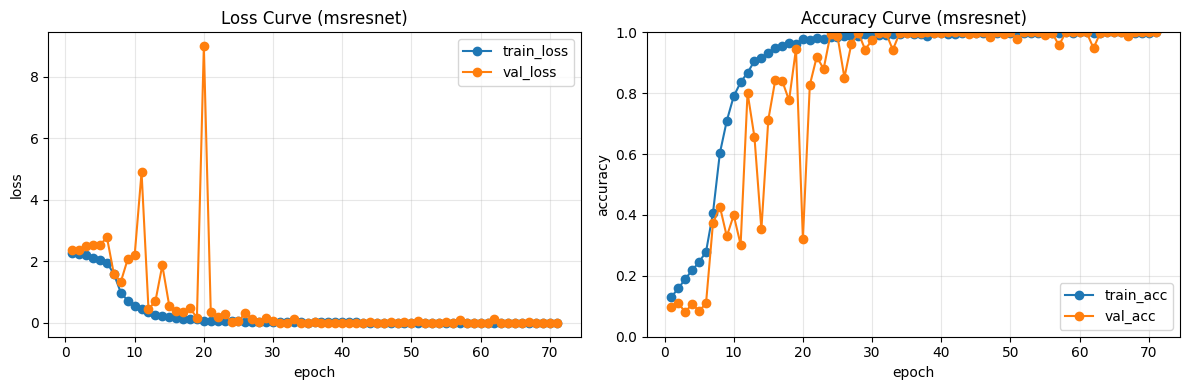

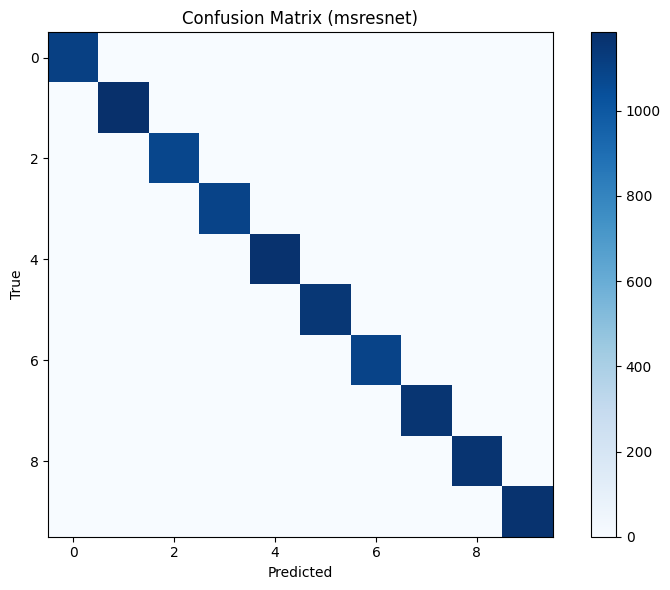


Training finished for: ['resmlp', 'msresnet']


In [1]:
import sys
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import confusion_matrix, classification_report
import torch

# ===== 可调参数 =====
TRAIN_VARIANTS = ["resmlp", "msresnet"]
EPOCHS = 100
BATCH_SIZE = 128
LEARNING_RATE = 1e-3
PATIENCE = 25
SEED = 42

# ===== 路径与依赖（独立于后续单元） =====
NOTEBOOK_DIR = Path.cwd()
search_roots = [NOTEBOOK_DIR, *NOTEBOOK_DIR.parents]
PROJECT_ROOT = next(
    (p for p in search_roots if (p / "processed_data").exists() and (p / "training_runner").exists()),
    NOTEBOOK_DIR,
 )
DATA_ROOT = PROJECT_ROOT / "processed_data"

if str(PROJECT_ROOT.parent) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT.parent))

from music_eeg.model_define.models import EEGResMLPNet, EEGMSResNet1D

torch.manual_seed(SEED)
np.random.seed(SEED)
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
print("device:", device)
print("DATA_ROOT:", DATA_ROOT)

# ===== 读取数据（只读一次） =====
train_df = pd.read_csv(DATA_ROOT / "train_features.csv")
val_df = pd.read_csv(DATA_ROOT / "val_features.csv")
test_df = pd.read_csv(DATA_ROOT / "test_features.csv")

non_feature_cols = {
    "label", "subject_id", "session_id", "recording_id", "song_id",
    "trial_id", "window_id", "group_id",
}
feature_cols = [
    c for c in train_df.columns
    if c not in non_feature_cols and pd.api.types.is_numeric_dtype(train_df[c])
]
if not feature_cols:
    raise ValueError("未找到可用数值特征列")

x_train = train_df[feature_cols].values.astype(np.float32)
x_val = val_df[feature_cols].values.astype(np.float32)
x_test = test_df[feature_cols].values.astype(np.float32)

le = LabelEncoder()
y_train = le.fit_transform(train_df["label"].astype(str).values)
y_val = le.transform(val_df["label"].astype(str).values)
y_test = le.transform(test_df["label"].astype(str).values)
n_classes = len(le.classes_)

x_mean = x_train.mean(axis=0, keepdims=True)
x_std = x_train.std(axis=0, keepdims=True) + 1e-6
x_train_n = ((x_train - x_mean) / x_std).astype(np.float32)
x_val_n = ((x_val - x_mean) / x_std).astype(np.float32)
x_test_n = ((x_test - x_mean) / x_std).astype(np.float32)

def build_tensors(variant: str):
    if variant == "msresnet":
        return (
            torch.from_numpy(x_train_n).unsqueeze(1),
            torch.from_numpy(x_val_n).unsqueeze(1),
            torch.from_numpy(x_test_n).unsqueeze(1),
        )
    return (
        torch.from_numpy(x_train_n),
        torch.from_numpy(x_val_n),
        torch.from_numpy(x_test_n),
    )

def build_model(variant: str):
    if variant == "msresnet":
        return EEGMSResNet1D(_input_len=x_train_n.shape[1], n_classes=n_classes).to(device)
    if variant == "resmlp":
        return EEGResMLPNet(input_dim=x_train_n.shape[1], n_classes=n_classes).to(device)
    raise ValueError(f"unknown variant: {variant}")

results = {}
for variant in TRAIN_VARIANTS:
    print(f"\n===== Train variant: {variant} =====")
    torch.manual_seed(SEED)
    np.random.seed(SEED)

    x_train_t, x_val_t, x_test_t = build_tensors(variant)
    y_train_t = torch.from_numpy(y_train).long()
    y_val_t = torch.from_numpy(y_val).long()
    y_test_t = torch.from_numpy(y_test).long()

    train_loader = torch.utils.data.DataLoader(
        torch.utils.data.TensorDataset(x_train_t, y_train_t),
        batch_size=BATCH_SIZE,
        shuffle=True,
        pin_memory=(device.type == "cuda"),
    )
    val_loader = torch.utils.data.DataLoader(
        torch.utils.data.TensorDataset(x_val_t, y_val_t),
        batch_size=BATCH_SIZE,
        shuffle=False,
        pin_memory=(device.type == "cuda"),
    )
    test_loader = torch.utils.data.DataLoader(
        torch.utils.data.TensorDataset(x_test_t, y_test_t),
        batch_size=BATCH_SIZE,
        shuffle=False,
        pin_memory=(device.type == "cuda"),
    )

    model = build_model(variant)
    optimizer = torch.optim.AdamW(model.parameters(), lr=LEARNING_RATE, weight_decay=2e-3)
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
        optimizer, T_max=max(EPOCHS, 10), eta_min=1e-5
    )
    criterion = torch.nn.CrossEntropyLoss()
    scaler = torch.amp.GradScaler("cuda", enabled=(device.type == "cuda"))

    history = {"train_loss": [], "val_loss": [], "train_acc": [], "val_acc": []}
    best_state = None
    best_val_acc = -1.0
    wait = 0

    for epoch in range(1, EPOCHS + 1):
        model.train()
        train_loss_sum = 0.0
        train_correct = 0
        train_total = 0

        for xb, yb in train_loader:
            xb = xb.to(device, non_blocking=(device.type == "cuda"))
            yb = yb.to(device, non_blocking=(device.type == "cuda"))

            optimizer.zero_grad()
            with torch.autocast(
                device_type="cuda", dtype=torch.float16, enabled=(device.type == "cuda")
            ):
                logits = model(xb)
                loss = criterion(logits, yb)
            scaler.scale(loss).backward()
            scaler.step(optimizer)
            scaler.update()

            train_loss_sum += loss.item() * yb.size(0)
            pred = logits.argmax(dim=1)
            train_correct += (pred == yb).sum().item()
            train_total += yb.size(0)

        scheduler.step()

        model.eval()
        val_loss_sum = 0.0
        val_correct = 0
        val_total = 0
        with torch.no_grad():
            for xb, yb in val_loader:
                xb = xb.to(device, non_blocking=(device.type == "cuda"))
                yb = yb.to(device, non_blocking=(device.type == "cuda"))
                with torch.autocast(
                    device_type="cuda", dtype=torch.float16, enabled=(device.type == "cuda")
                ):
                    logits = model(xb)
                    loss = criterion(logits, yb)
                val_loss_sum += loss.item() * yb.size(0)
                pred = logits.argmax(dim=1)
                val_correct += (pred == yb).sum().item()
                val_total += yb.size(0)

        train_loss = train_loss_sum / max(train_total, 1)
        val_loss = val_loss_sum / max(val_total, 1)
        train_acc = train_correct / max(train_total, 1)
        val_acc = val_correct / max(val_total, 1)

        history["train_loss"].append(train_loss)
        history["val_loss"].append(val_loss)
        history["train_acc"].append(train_acc)
        history["val_acc"].append(val_acc)

        print(
            f"[{variant}] Epoch {epoch:03d} | train_loss={train_loss:.4f} "
            f"val_loss={val_loss:.4f} train_acc={train_acc:.4f} val_acc={val_acc:.4f}"
        )

        if val_acc > best_val_acc:
            best_val_acc = val_acc
            wait = 0
            best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
        else:
            wait += 1
            if wait >= PATIENCE:
                print(f"[{variant}] Early stop at epoch={epoch}")
                break

    if best_state is None:
        raise RuntimeError(f"{variant} 训练失败：未获得有效最优模型")

    model.load_state_dict(best_state)
    model.eval()

    all_true, all_pred = [], []
    with torch.no_grad():
        for xb, yb in test_loader:
            xb = xb.to(device, non_blocking=(device.type == "cuda"))
            with torch.autocast(
                device_type="cuda", dtype=torch.float16, enabled=(device.type == "cuda")
            ):
                logits = model(xb)
            pred = logits.argmax(dim=1).cpu().numpy()
            all_pred.extend(pred.tolist())
            all_true.extend(yb.numpy().tolist())

    cm = confusion_matrix(all_true, all_pred)
    test_acc = float(np.mean(np.array(all_true) == np.array(all_pred)))
    report = classification_report(
        all_true, all_pred, target_names=le.classes_, zero_division=0
    )
    print(f"[{variant}] test_acc={test_acc:.4f}")
    print(report)

    # 曲线图
    epochs_axis = np.arange(1, len(history["train_loss"]) + 1)
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    axes[0].plot(epochs_axis, history["train_loss"], marker="o", label="train_loss")
    axes[0].plot(epochs_axis, history["val_loss"], marker="o", label="val_loss")
    axes[0].set_title(f"Loss Curve ({variant})")
    axes[0].set_xlabel("epoch")
    axes[0].set_ylabel("loss")
    axes[0].legend()
    axes[0].grid(alpha=0.3)

    axes[1].plot(epochs_axis, history["train_acc"], marker="o", label="train_acc")
    axes[1].plot(epochs_axis, history["val_acc"], marker="o", label="val_acc")
    axes[1].set_title(f"Accuracy Curve ({variant})")
    axes[1].set_xlabel("epoch")
    axes[1].set_ylabel("accuracy")
    axes[1].set_ylim(0, 1)
    axes[1].legend()
    axes[1].grid(alpha=0.3)
    plt.tight_layout()
    plt.show()

    # 混淆矩阵
    plt.figure(figsize=(8, 6))
    if 'sns' in globals() and sns is not None:
        sns.heatmap(cm, cmap="Blues", annot=False)
    else:
        plt.imshow(cm, cmap="Blues")
        plt.colorbar()
    plt.title(f"Confusion Matrix ({variant})")
    plt.xlabel("Predicted")
    plt.ylabel("True")
    plt.tight_layout()
    plt.show()

    results[variant] = {
        "history": history,
        "test_acc": test_acc,
        "confusion_matrix": cm,
        "classification_report": report,
    }

print("\nTraining finished for:", list(results.keys()))

# 自动对比报告（EEG）

一个用于自动汇总不同配置实验结果并生成对比报告的 notebook，覆盖 val/test/macro_f1、消融实验和可视化图表。

## 1. 导入依赖与全局配置

导入 pandas、numpy、matplotlib、seaborn、scipy、pathlib；设置随机种子、显示风格、输入输出目录、主指标名称（macro_f1）和对比维度。

In [2]:
from pathlib import Path
import json
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

try:
    import seaborn as sns
except Exception:
    sns = None

try:
    from scipy import stats
except Exception:
    stats = None

SEED = 42
np.random.seed(SEED)

if sns is not None:
    sns.set_theme(style="whitegrid")

NOTEBOOK_DIR = Path.cwd()
search_roots = [NOTEBOOK_DIR, *NOTEBOOK_DIR.parents]
PROJECT_ROOT = next(
    (p for p in search_roots if (p / "processed_data").exists() and (p / "training_runner").exists()),
    NOTEBOOK_DIR,
 )
DATA_ROOT = PROJECT_ROOT / "processed_data"
ROOT = PROJECT_ROOT / "training_runner" / "results"
ROOT.mkdir(parents=True, exist_ok=True)

FIG_DIR = ROOT / "figures"
FIG_DIR.mkdir(parents=True, exist_ok=True)

MAIN_METRIC = "test_macro_f1"
COMPARE_DIMS = ["best_model", "model_variant", "deep_loss", "use_onecycle", "run_classical_models"]

print("PROJECT_ROOT:", PROJECT_ROOT)
print("DATA_ROOT:", DATA_ROOT)
print("RESULT_ROOT:", ROOT)
print("FIG_DIR:", FIG_DIR)
print("MAIN_METRIC:", MAIN_METRIC)
print("COMPARE_DIMS:", COMPARE_DIMS)

PROJECT_ROOT: c:\projects\music_eeg\music_eeg
DATA_ROOT: c:\projects\music_eeg\music_eeg\processed_data
RESULT_ROOT: c:\projects\music_eeg\music_eeg\training_runner\results
FIG_DIR: c:\projects\music_eeg\music_eeg\training_runner\results\figures
MAIN_METRIC: test_macro_f1
COMPARE_DIMS: ['best_model', 'model_variant', 'deep_loss', 'use_onecycle', 'run_classical_models']


## 2. 读取多配置实验结果（val/test/macro_f1）

从 JSON/CSV 批量读取实验结果，提取 run_id、配置字段、val/test/macro_f1，并记录读取失败项。

In [3]:
grid_dir = ROOT / "ablation_grid"
grid_json_files = sorted(grid_dir.glob("grid_*.json")) if grid_dir.exists() else []

# Prefer complete factorial grid reports when available.
if grid_json_files:
    json_files = grid_json_files
    report_scope = "ablation_grid"
else:
    json_files = sorted(
        p for p in ROOT.glob("*.json") if p.name not in {"split_summary.json", "nmedt_features.summary.json"}
    )
    report_scope = "root"

csv_files = sorted(ROOT.glob("*.csv"))

errors = []
rows = []
report_payloads = {}

for p in json_files:
    try:
        payload = json.loads(p.read_text(encoding="utf-8"))
    except Exception as exc:
        errors.append({"file": p.name, "error": str(exc)})
        continue

    if not isinstance(payload, dict):
        errors.append({"file": p.name, "error": "json root is not object"})
        continue

    report_payloads[p.name] = payload
    row = {
        "run_id": p.stem,
        "report_file": p.name,
        "best_model": payload.get("best_model"),
        "val_macro_f1": payload.get("best_val_accuracy"),
        "test_accuracy": payload.get("test_accuracy"),
        "test_balanced_accuracy": payload.get("test_balanced_accuracy"),
        "test_macro_f1": payload.get("test_macro_f1"),
        "model_variant": payload.get("model_variant"),
        "deep_loss": payload.get("deep_loss"),
        "use_onecycle": payload.get("use_onecycle"),
        "run_classical_models": payload.get("run_classical_models"),
    }

    note = p.stem.lower()
    if row["model_variant"] is None:
        if "msresnet" in note:
            row["model_variant"] = "msresnet"
        elif "resmlp" in note:
            row["model_variant"] = "resmlp"

    if row["deep_loss"] is None:
        if "focal" in note:
            row["deep_loss"] = "focal"
        elif "ce" in note:
            row["deep_loss"] = "ce"

    if row["use_onecycle"] is None:
        row["use_onecycle"] = "onecycle" in note

    rows.append(row)

raw_df = pd.DataFrame(rows)
error_df = pd.DataFrame(errors)

print(f"Report scope: {report_scope}")
print("JSON reports:", len(json_files), "| Parsed:", len(raw_df), "| Read errors:", len(error_df))
if not error_df.empty:
    display(error_df)

raw_df.head()

Report scope: ablation_grid
JSON reports: 8 | Parsed: 8 | Read errors: 0


,run_id,report_file,best_model,val_macro_f1,test_accuracy,test_balanced_accuracy,test_macro_f1,model_variant,deep_loss,use_onecycle,run_classical_models
0,grid_msresnet_ce_oc_off,grid_msresnet_ce_oc_off.json,eeg_msresnet,0.827268,0.858034,0.858467,0.858220,msresnet,ce,False,False
1,grid_msresnet_ce_oc_on,grid_msresnet_ce_oc_on.json,eeg_msresnet,0.819884,0.853639,0.854197,0.854096,msresnet,ce,True,False
2,grid_msresnet_focal_oc_off,grid_msresnet_focal_oc_off.json,eeg_msresnet,0.881153,0.925105,0.925063,0.924267,msresnet,focal,False,False
3,grid_msresnet_focal_oc_on,grid_msresnet_focal_oc_on.json,eeg_msresnet,0.889328,0.929325,0.929243,0.928536,msresnet,focal,True,False
4,grid_resmlp_ce_oc_off,grid_resmlp_ce_oc_off.json,eeg_resmlp,0.348717,0.283667,0.281725,0.259563,resmlp,ce,False,False


## 3. 结果表标准化与字段校验

统一列名和类型，处理重复 run、缺失值、异常值，输出数据质量检查表。

In [4]:
df = raw_df.copy()
for c in ["val_macro_f1", "test_accuracy", "test_balanced_accuracy", "test_macro_f1"]:
    df[c] = pd.to_numeric(df[c], errors="coerce")

df["run_id"] = df["run_id"].astype(str)
df = df.drop_duplicates(subset=["run_id"], keep="last")

required_cols = ["run_id", "best_model", "val_macro_f1", "test_macro_f1"]
missing_required = df[required_cols].isna().any(axis=1)

quality = pd.DataFrame({
    "n_rows": [len(df)],
    "n_missing_required": [int(missing_required.sum())],
    "n_metric_out_of_range": [
        int(((df[["val_macro_f1", "test_macro_f1", "test_accuracy"]] < 0) | (df[["val_macro_f1", "test_macro_f1", "test_accuracy"]] > 1)).sum().sum())
    ],
})

display(quality)
if missing_required.any():
    display(df.loc[missing_required, required_cols])

df.head()

,n_rows,n_missing_required,n_metric_out_of_range
0,8,0,0


,run_id,report_file,best_model,val_macro_f1,test_accuracy,test_balanced_accuracy,test_macro_f1,model_variant,deep_loss,use_onecycle,run_classical_models
0,grid_msresnet_ce_oc_off,grid_msresnet_ce_oc_off.json,eeg_msresnet,0.827268,0.858034,0.858467,0.858220,msresnet,ce,False,False
1,grid_msresnet_ce_oc_on,grid_msresnet_ce_oc_on.json,eeg_msresnet,0.819884,0.853639,0.854197,0.854096,msresnet,ce,True,False
2,grid_msresnet_focal_oc_off,grid_msresnet_focal_oc_off.json,eeg_msresnet,0.881153,0.925105,0.925063,0.924267,msresnet,focal,False,False
3,grid_msresnet_focal_oc_on,grid_msresnet_focal_oc_on.json,eeg_msresnet,0.889328,0.929325,0.929243,0.928536,msresnet,focal,True,False
4,grid_resmlp_ce_oc_off,grid_resmlp_ce_oc_off.json,eeg_resmlp,0.348717,0.283667,0.281725,0.259563,resmlp,ce,False,False


## 4. 按配置聚合与主指标排名

按配置分组计算均值/标准差/样本数，输出 val/test 的 macro_f1 排名与 Top-K，并标记相对基线提升。

In [5]:
group_cols = [c for c in ["model_variant", "best_model", "deep_loss", "use_onecycle", "run_classical_models"] if c in df.columns]
agg = (
    df.groupby(group_cols, dropna=False)
    .agg(
        n_runs=("run_id", "count"),
        val_mean=("val_macro_f1", "mean"),
        val_std=("val_macro_f1", "std"),
        test_mean=("test_macro_f1", "mean"),
        test_std=("test_macro_f1", "std"),
        test_acc_mean=("test_accuracy", "mean"),
    )
    .reset_index()
)

baseline_row = agg.sort_values("test_mean", ascending=False).head(1)
baseline_test = float(baseline_row["test_mean"].iloc[0]) if not baseline_row.empty else np.nan
agg["gain_abs_vs_best"] = agg["test_mean"] - baseline_test
agg["gain_rel_vs_best"] = np.where(np.abs(baseline_test) > 1e-12, agg["gain_abs_vs_best"] / baseline_test, np.nan)

val_rank = agg.sort_values(["val_mean", "test_mean"], ascending=False)
test_rank = agg.sort_values(["test_mean", "val_mean"], ascending=False)

display(val_rank.head(10))
display(test_rank.head(10))

top_k = test_rank.head(5).copy()
print("Top-K configurations by test macro_f1")
display(top_k)

,model_variant,best_model,deep_loss,use_onecycle,run_classical_models,n_runs,val_mean,val_std,test_mean,test_std,test_acc_mean,gain_abs_vs_best,gain_rel_vs_best
3,msresnet,eeg_msresnet,focal,True,False,1,0.889328,NaN,0.928536,NaN,0.929325,0.000000,0.000000
2,msresnet,eeg_msresnet,focal,False,False,1,0.881153,NaN,0.924267,NaN,0.925105,-0.004269,-0.004598
0,msresnet,eeg_msresnet,ce,False,False,1,0.827268,NaN,0.858220,NaN,0.858034,-0.070316,-0.075727
1,msresnet,eeg_msresnet,ce,True,False,1,0.819884,NaN,0.854096,NaN,0.853639,-0.074440,-0.080169
7,resmlp,eeg_resmlp,focal,True,False,1,0.372099,NaN,0.287059,NaN,0.320236,-0.641477,-0.690847
5,resmlp,eeg_resmlp,ce,True,False,1,0.363221,NaN,0.288165,NaN,0.310918,-0.640371,-0.689657
4,resmlp,eeg_resmlp,ce,False,False,1,0.348717,NaN,0.259563,NaN,0.283667,-0.668973,-0.720460
6,resmlp,eeg_resmlp,focal,False,False,1,0.340893,NaN,0.276996,NaN,0.291930,-0.651539,-0.701685


,model_variant,best_model,deep_loss,use_onecycle,run_classical_models,n_runs,val_mean,val_std,test_mean,test_std,test_acc_mean,gain_abs_vs_best,gain_rel_vs_best
3,msresnet,eeg_msresnet,focal,True,False,1,0.889328,NaN,0.928536,NaN,0.929325,0.000000,0.000000
2,msresnet,eeg_msresnet,focal,False,False,1,0.881153,NaN,0.924267,NaN,0.925105,-0.004269,-0.004598
0,msresnet,eeg_msresnet,ce,False,False,1,0.827268,NaN,0.858220,NaN,0.858034,-0.070316,-0.075727
1,msresnet,eeg_msresnet,ce,True,False,1,0.819884,NaN,0.854096,NaN,0.853639,-0.074440,-0.080169
5,resmlp,eeg_resmlp,ce,True,False,1,0.363221,NaN,0.288165,NaN,0.310918,-0.640371,-0.689657
7,resmlp,eeg_resmlp,focal,True,False,1,0.372099,NaN,0.287059,NaN,0.320236,-0.641477,-0.690847
6,resmlp,eeg_resmlp,focal,False,False,1,0.340893,NaN,0.276996,NaN,0.291930,-0.651539,-0.701685
4,resmlp,eeg_resmlp,ce,False,False,1,0.348717,NaN,0.259563,NaN,0.283667,-0.668973,-0.720460


Top-K configurations by test macro_f1


,model_variant,best_model,deep_loss,use_onecycle,run_classical_models,n_runs,val_mean,val_std,test_mean,test_std,test_acc_mean,gain_abs_vs_best,gain_rel_vs_best
3,msresnet,eeg_msresnet,focal,True,False,1,0.889328,NaN,0.928536,NaN,0.929325,0.000000,0.000000
2,msresnet,eeg_msresnet,focal,False,False,1,0.881153,NaN,0.924267,NaN,0.925105,-0.004269,-0.004598
0,msresnet,eeg_msresnet,ce,False,False,1,0.827268,NaN,0.858220,NaN,0.858034,-0.070316,-0.075727
1,msresnet,eeg_msresnet,ce,True,False,1,0.819884,NaN,0.854096,NaN,0.853639,-0.074440,-0.080169
5,resmlp,eeg_resmlp,ce,True,False,1,0.363221,NaN,0.288165,NaN,0.310918,-0.640371,-0.689657


## 5. 自动生成消融实验对比表

定义 baseline 配置与可变因子，计算单因子改动对 val/test macro_f1 的增益 Δ。

In [6]:
if agg.empty:
    ablation_df = pd.DataFrame()
else:
    # Pairwise ablation within the same model family to avoid global placeholder deltas.
    compare_factors = [
        c for c in ["deep_loss", "use_onecycle", "run_classical_models"] if c in agg.columns
    ]
    fixed_keys = [c for c in ["model_variant"] if c in agg.columns]
    rows = []

    if fixed_keys:
        grouped_fixed = agg.groupby(fixed_keys, dropna=False)
    else:
        grouped_fixed = [("all", agg)]

    for fixed_vals, fixed_group in grouped_fixed:
        if not isinstance(fixed_vals, tuple):
            fixed_vals = (fixed_vals,)
        fixed_ctx = dict(zip(fixed_keys, fixed_vals)) if fixed_keys else {}

        for fac in compare_factors:
            fac_summary = (
                fixed_group.dropna(subset=[fac, "test_mean", "val_mean"])
                .groupby(fac, dropna=False)
                .agg(
                    val_mean=("val_mean", "mean"),
                    test_mean=("test_mean", "mean"),
                    n_runs=("n_runs", "sum"),
                )
                .reset_index()
            )

            if len(fac_summary) < 2:
                continue

            best = fac_summary.sort_values("test_mean", ascending=False).iloc[0]
            for _, cur in fac_summary.iterrows():
                if str(cur[fac]) == str(best[fac]):
                    continue
                rows.append(
                    {
                        **fixed_ctx,
                        "factor": fac,
                        "from": cur[fac],
                        "to": best[fac],
                        "val_delta": float(best["val_mean"] - cur["val_mean"]),
                        "test_delta": float(best["test_mean"] - cur["test_mean"]),
                        "from_test_mean": float(cur["test_mean"]),
                        "to_test_mean": float(best["test_mean"]),
                        "n_runs_from": int(cur["n_runs"]),
                        "n_runs_to": int(best["n_runs"]),
                    }
                )

    ablation_df = pd.DataFrame(rows)
    if not ablation_df.empty:
        ablation_df = ablation_df.sort_values(
            ["test_delta", "val_delta"], ascending=False
        ).reset_index(drop=True)

ablation_df.head(30) if not ablation_df.empty else "Ablation table is empty"

,model_variant,factor,from,to,val_delta,test_delta,from_test_mean,to_test_mean,n_runs_from,n_runs_to
0,msresnet,deep_loss,ce,focal,0.061665,0.070243,0.856158,0.926401,2,2
1,resmlp,use_onecycle,False,True,0.022855,0.019332,0.268280,0.287612,2,2
2,resmlp,deep_loss,ce,focal,0.000527,0.008164,0.273864,0.282028,2,2
3,msresnet,use_onecycle,False,True,0.000396,0.000072,0.891244,0.891316,2,2


## 6. 绘制对比图表（柱状图/折线图/热力图）

绘制配置-指标柱状图、消融增益条形图、参数组合热力图；若有 epoch 数据则绘制趋势（当前报告无 epoch 明细时自动跳过）。

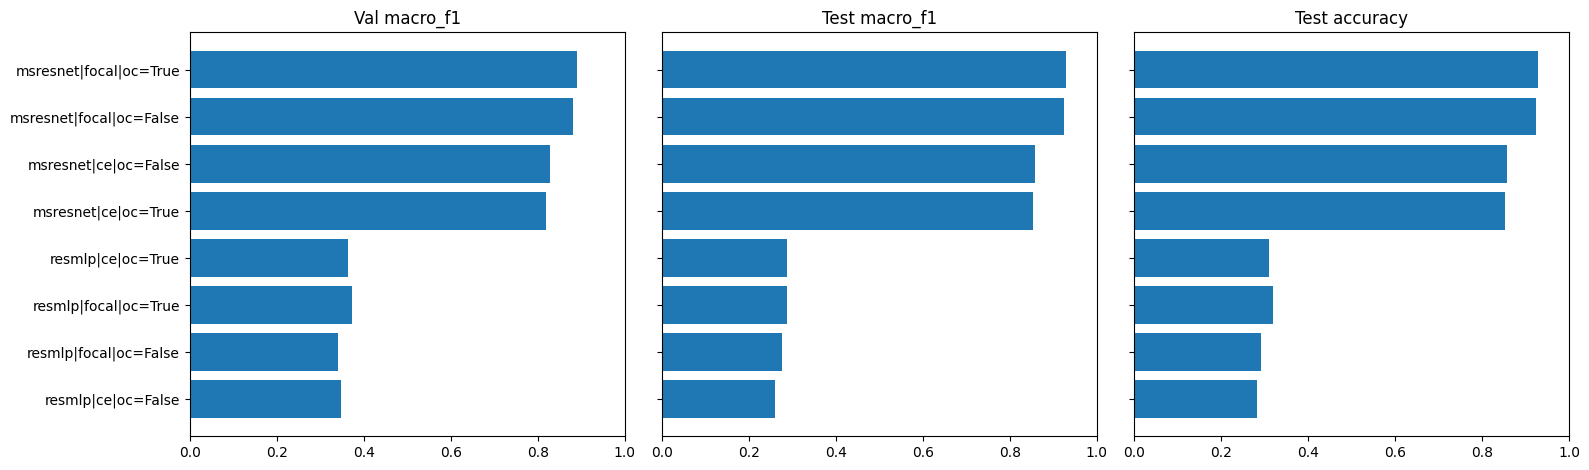

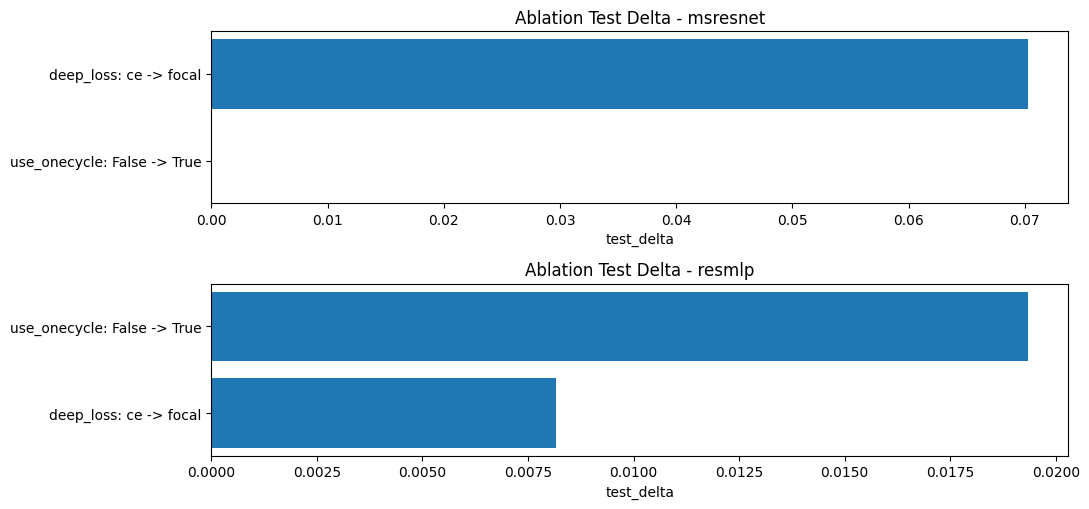

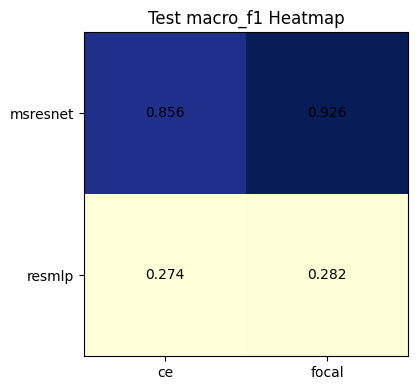

In [7]:
if not agg.empty:
    plot_df = test_rank.head(min(10, len(test_rank))).copy().iloc[::-1]
    labels = (
        plot_df["model_variant"].astype(str)
        + "|"
        + plot_df["deep_loss"].astype(str)
        + "|oc="
        + plot_df["use_onecycle"].astype(str)
    )

    fig, axes = plt.subplots(1, 3, figsize=(16, max(4, len(plot_df) * 0.6)), sharey=True)
    axes[0].barh(labels, plot_df["val_mean"])
    axes[0].set_title("Val macro_f1")
    axes[0].set_xlim(0, 1)

    axes[1].barh(labels, plot_df["test_mean"])
    axes[1].set_title("Test macro_f1")
    axes[1].set_xlim(0, 1)

    axes[2].barh(labels, plot_df["test_acc_mean"])
    axes[2].set_title("Test accuracy")
    axes[2].set_xlim(0, 1)

    plt.tight_layout()
    p1 = FIG_DIR / "metrics_barh.png"
    plt.savefig(p1, dpi=180)
    plt.show()

    if not ablation_df.empty:
        if "model_variant" in ablation_df.columns and ablation_df["model_variant"].notna().any():
            model_list = [m for m in sorted(ablation_df["model_variant"].dropna().unique())]
            fig_h = max(4, 2.6 * len(model_list))
            fig, axes = plt.subplots(len(model_list), 1, figsize=(11, fig_h), squeeze=False)

            for i, mv in enumerate(model_list):
                ax = axes[i, 0]
                part = ablation_df[ablation_df["model_variant"] == mv].copy()
                part = part.sort_values("test_delta", ascending=True)
                y = part["factor"].astype(str) + ": " + part["from"].astype(str) + " -> " + part["to"].astype(str)

                ax.barh(y, part["test_delta"].astype(float))
                ax.set_title(f"Ablation Test Delta - {mv}")
                ax.set_xlabel("test_delta")

            plt.tight_layout()
            p2 = FIG_DIR / "ablation_delta_by_model.png"
            plt.savefig(p2, dpi=180)
            plt.show()
        else:
            top_ab = ablation_df.head(min(15, len(ablation_df))).iloc[::-1]
            plt.figure(figsize=(10, max(4, len(top_ab) * 0.4)))
            plt.barh(top_ab["factor"].astype(str) + ": " + top_ab["to"].astype(str), top_ab["test_delta"])
            plt.title("Ablation Test Delta")
            plt.tight_layout()
            p2 = FIG_DIR / "ablation_delta_barh.png"
            plt.savefig(p2, dpi=180)
            plt.show()

    if {"model_variant", "deep_loss", "test_mean"}.issubset(agg.columns):
        pivot = agg.pivot_table(index="model_variant", columns="deep_loss", values="test_mean", aggfunc="mean")
        if not pivot.empty:
            plt.figure(figsize=(6, 4))
            if sns is not None:
                sns.heatmap(pivot, annot=True, fmt=".3f", cmap="YlGnBu")
            else:
                plt.imshow(pivot.values, cmap="YlGnBu")
                plt.xticks(range(pivot.shape[1]), pivot.columns)
                plt.yticks(range(pivot.shape[0]), pivot.index)
                for i in range(pivot.shape[0]):
                    for j in range(pivot.shape[1]):
                        plt.text(j, i, f"{pivot.values[i, j]:.3f}", ha="center", va="center")
            plt.title("Test macro_f1 Heatmap")
            plt.tight_layout()
            p3 = FIG_DIR / "config_heatmap.png"
            plt.savefig(p3, dpi=180)
            plt.show()
else:
    print("No aggregated data to plot.")

## 7. 统计显著性与置信区间计算

对关键配置进行配对检验（若样本数允许）并计算 95% 置信区间。

In [8]:
sig_rows = []
ci_rows = []

if not agg.empty:
    grouped = df.groupby(["model_variant", "deep_loss", "use_onecycle"], dropna=False)
    for key, g in grouped:
        vals = g["test_macro_f1"].dropna().values
        if len(vals) == 0:
            continue
        mean = float(np.mean(vals))
        std = float(np.std(vals, ddof=1)) if len(vals) > 1 else 0.0
        se = std / np.sqrt(len(vals)) if len(vals) > 1 else 0.0
        ci95 = 1.96 * se
        ci_rows.append({
            "config": str(key),
            "n": len(vals),
            "mean": mean,
            "ci95_low": mean - ci95,
            "ci95_high": mean + ci95,
        })

    if stats is not None and len(ci_rows) >= 2:
        best_cfg = max(ci_rows, key=lambda x: x["mean"])['config']
        best_group = None
        for key, g in grouped:
            if str(key) == best_cfg:
                best_group = g["test_macro_f1"].dropna().values
                break

        for key, g in grouped:
            cfg = str(key)
            cur = g["test_macro_f1"].dropna().values
            if cfg == best_cfg or best_group is None:
                continue
            n = min(len(best_group), len(cur))
            if n < 2:
                continue
            a = best_group[:n]
            b = cur[:n]
            try:
                p_val = float(stats.ttest_rel(a, b).pvalue)
            except Exception:
                p_val = np.nan
            sig_rows.append({
                "best_cfg": best_cfg,
                "compared_cfg": cfg,
                "n": n,
                "p_value": p_val,
                "significant_0_05": bool(p_val < 0.05) if pd.notna(p_val) else False,
            })

ci_df = pd.DataFrame(ci_rows).sort_values("mean", ascending=False)
sig_df = pd.DataFrame(sig_rows)

display(ci_df)
display(sig_df if not sig_df.empty else pd.DataFrame([{"info": "Not enough repeated runs for significance test."}]))

,config,n,mean,ci95_low,ci95_high
3,"('msresnet', 'focal', True)",1,0.928536,0.928536,0.928536
2,"('msresnet', 'focal', False)",1,0.924267,0.924267,0.924267
0,"('msresnet', 'ce', False)",1,0.858220,0.858220,0.858220
1,"('msresnet', 'ce', True)",1,0.854096,0.854096,0.854096
5,"('resmlp', 'ce', True)",1,0.288165,0.288165,0.288165
7,"('resmlp', 'focal', True)",1,0.287059,0.287059,0.287059
6,"('resmlp', 'focal', False)",1,0.276996,0.276996,0.276996
4,"('resmlp', 'ce', False)",1,0.259563,0.259563,0.259563


,info
0,Not enough repeated runs for significance test.


## 8. 生成最终汇总表并导出报告文件

导出 comparison_report.csv、ablation_report.csv、significance_report.csv，并输出图表目录。

In [9]:
summary_out = ROOT / "comparison_report.csv"
ablation_out = ROOT / "ablation_report.csv"
sig_out = ROOT / "significance_report.csv"

if not test_rank.empty:
    test_rank.to_csv(summary_out, index=False, encoding="utf-8-sig")
if not ablation_df.empty:
    ablation_df.to_csv(ablation_out, index=False, encoding="utf-8-sig")
if not sig_df.empty:
    sig_df.to_csv(sig_out, index=False, encoding="utf-8-sig")

best_config = test_rank.iloc[0].to_dict() if not test_rank.empty else {}
second_config = test_rank.iloc[1].to_dict() if len(test_rank) > 1 else {}

final_summary = pd.DataFrame([
    {
        "best_config": str(best_config),
        "second_config": str(second_config),
        "n_reports": len(df),
        "summary_csv": str(summary_out),
        "ablation_csv": str(ablation_out if ablation_out.exists() else ""),
        "significance_csv": str(sig_out if sig_out.exists() else ""),
        "fig_dir": str(FIG_DIR),
    }
])

print("Export completed.")
display(final_summary)

Export completed.


,best_config,second_config,n_reports,summary_csv,ablation_csv,significance_csv,fig_dir
0,"{'model_variant': 'msresnet', 'best_model': 'e...","{'model_variant': 'msresnet', 'best_model': 'e...",8,c:\projects\music_eeg\music_eeg\training_runne...,c:\projects\music_eeg\music_eeg\training_runne...,,c:\projects\music_eeg\music_eeg\training_runne...
